<a href="https://colab.research.google.com/github/kupadhyay5518/Ecommerce-Sales-Dashboard/blob/main/Untitled4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import sys
!{sys.executable} -m pip install pandas numpy matplotlib seaborn scikit-learn plotly --quiet
print('✅ Libraries installed!')

✅ Libraries installed!


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
from datetime import datetime, timedelta

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

warnings.filterwarnings('ignore')
sns.set_theme(style='darkgrid', palette='muted')
plt.rcParams['figure.figsize'] = (13, 5)
np.random.seed(42)

print('✅ All libraries imported!')

✅ All libraries imported!


In [3]:
N = 20000

# ── Config ──────────────────────────────────────────────────────────────────
categories = {
    'Electronics'  : {'price_range': (3000, 80000), 'weight': 0.20},
    'Fashion'      : {'price_range': (299,  5000),  'weight': 0.28},
    'Home & Kitchen': {'price_range': (199, 12000),  'weight': 0.18},
    'Beauty'       : {'price_range': (99,   3000),  'weight': 0.12},
    'Sports'       : {'price_range': (299,  8000),  'weight': 0.12},
    'Books'        : {'price_range': (99,    999),  'weight': 0.10},
}

products = {
    'Electronics'   : ['Smartphone','Laptop','Headphones','Smart Watch','Tablet','Camera','Speaker'],
    'Fashion'       : ['T-Shirt','Jeans','Dress','Sneakers','Jacket','Saree','Kurta'],
    'Home & Kitchen': ['Mixer Grinder','Bed Sheet','Pressure Cooker','Curtains','Lamp','Pillow','Cookware'],
    'Beauty'        : ['Face Cream','Shampoo','Lipstick','Perfume','Sunscreen','Foundation','Serum'],
    'Sports'        : ['Yoga Mat','Cricket Bat','Dumbbells','Running Shoes','Cycle','Badminton Kit','Skipping Rope'],
    'Books'         : ['Fiction Novel','Self Help','Textbook','Comic','Cookbook','Biography','Children Book'],
}

cities = {
    'Mumbai'   : 0.18, 'Delhi'    : 0.16, 'Bangalore': 0.14,
    'Hyderabad': 0.11, 'Chennai'  : 0.10, 'Pune'     : 0.09,
    'Kolkata'  : 0.08, 'Ahmedabad': 0.07, 'Jaipur'   : 0.04, 'Lucknow': 0.03,
}

payment_methods = ['Credit Card','Debit Card','UPI','Net Banking','COD']
ship_modes      = ['Standard','Express','Same Day']
statuses        = ['Delivered','Returned','Cancelled','Pending']

# ── Date range: Jan 2023 – Dec 2024 ─────────────────────────────────────
start_date = datetime(2023, 1, 1)
end_date   = datetime(2024, 12, 31)
date_range = (end_date - start_date).days

# Seasonal weight: higher in Oct-Dec (festival season)
raw_dates  = [start_date + timedelta(days=int(d)) for d in np.random.randint(0, date_range, N)]
months     = np.array([d.month for d in raw_dates])
season_w   = np.where(months.isin([10,11,12]) if hasattr(months,'isin') else np.isin(months,[10,11,12]), 1.6, 1.0)
keep_mask  = np.random.uniform(0, 1.6, N) < season_w
final_dates= [d for d, k in zip(raw_dates, keep_mask) if k]
# Pad if needed
while len(final_dates) < N:
    final_dates.append(start_date + timedelta(days=int(np.random.randint(0, date_range))))
order_dates = np.random.choice(final_dates, N, replace=False if len(final_dates)>=N else True)

# ── Category & product sampling ──────────────────────────────────────────
cat_names   = list(categories.keys())
cat_weights = [categories[c]['weight'] for c in cat_names]
chosen_cats = np.random.choice(cat_names, N, p=cat_weights)

chosen_products, unit_prices, quantities = [], [], []
for cat in chosen_cats:
    prod = np.random.choice(products[cat])
    lo, hi = categories[cat]['price_range']
    price = round(np.random.uniform(lo, hi), -1)
    qty   = np.random.choice([1,1,1,2,2,3], p=[0.45,0.25,0.15,0.08,0.05,0.02])
    chosen_products.append(prod)
    unit_prices.append(price)
    quantities.append(qty)

unit_prices = np.array(unit_prices)
quantities  = np.array(quantities)
discounts   = np.random.choice([0, 5, 10, 15, 20, 25, 30], N,
                                p=[0.30,0.15,0.20,0.15,0.10,0.06,0.04])
revenue     = np.round(unit_prices * quantities * (1 - discounts/100), 2)
profit_margin = np.random.uniform(0.10, 0.35, N)
profit      = np.round(revenue * profit_margin, 2)

# ── Customer IDs (1000 unique customers) ─────────────────────────────────
customer_ids = [f'CUST{str(i).zfill(4)}' for i in range(1, 1001)]
chosen_customers = np.random.choice(customer_ids, N)

chosen_cities = np.random.choice(
    list(cities.keys()), N, p=list(cities.values())
)

df = pd.DataFrame({
    'order_id'      : [f'ORD{str(i).zfill(6)}' for i in range(1, N+1)],
    'order_date'    : order_dates,
    'customer_id'   : chosen_customers,
    'city'          : chosen_cities,
    'category'      : chosen_cats,
    'product'       : chosen_products,
    'quantity'      : quantities,
    'unit_price'    : unit_prices,
    'discount_pct'  : discounts,
    'revenue'       : revenue,
    'profit'        : profit,
    'payment_method': np.random.choice(payment_methods, N, p=[0.28,0.22,0.30,0.10,0.10]),
    'ship_mode'     : np.random.choice(ship_modes, N, p=[0.60,0.30,0.10]),
    'status'        : np.random.choice(statuses, N, p=[0.82,0.08,0.06,0.04]),
})

df['order_date'] = pd.to_datetime(df['order_date'])
df['month']      = df['order_date'].dt.month
df['month_name'] = df['order_date'].dt.strftime('%b')
df['year']       = df['order_date'].dt.year
df['quarter']    = df['order_date'].dt.quarter
df['day_of_week']= df['order_date'].dt.day_name()

print(f'✅ Dataset generated! Shape: {df.shape}')
print(f'   Orders       : {len(df):,}')
print(f'   Customers    : {df["customer_id"].nunique():,}')
print(f'   Total Revenue: ₹ {df["revenue"].sum()/1e7:.2f} Cr')
df.head(8)

✅ Dataset generated! Shape: (20000, 19)
   Orders       : 20,000
   Customers    : 1,000
   Total Revenue: ₹ 22.79 Cr


,order_id,order_date,customer_id,city,category,product,quantity,unit_price,discount_pct,revenue,profit,payment_method,ship_mode,status,month,month_name,year,quarter,day_of_week
0,ORD000001,2023-10-03,CUST0988,Mumbai,Fashion,Jacket,1,1070.0,0,1070.0,169.30,Credit Card,Standard,Delivered,10,Oct,2023,4,Tuesday
1,ORD000002,2023-08-19,CUST0541,Mumbai,Electronics,Headphones,1,59220.0,15,50337.0,17047.64,COD,Standard,Delivered,8,Aug,2023,3,Saturday
2,ORD000003,2024-02-11,CUST0416,Hyderabad,Fashion,T-Shirt,1,3480.0,10,3132.0,828.07,COD,Express,Returned,2,Feb,2024,1,Sunday
3,ORD000004,2023-07-10,CUST0321,Mumbai,Beauty,Lipstick,1,260.0,10,234.0,43.08,Credit Card,Standard,Delivered,7,Jul,2023,3,Monday
4,ORD000005,2023-11-15,CUST0509,Bangalore,Home & Kitchen,Lamp,1,920.0,5,874.0,223.51,UPI,Standard,Delivered,11,Nov,2023,4,Wednesday
5,ORD000006,2023-06-01,CUST0712,Chennai,Electronics,Speaker,1,6600.0,10,5940.0,673.66,UPI,Standard,Returned,6,Jun,2023,2,Thursday
6,ORD000007,2023-12-02,CUST0674,Mumbai,Fashion,Kurta,1,4500.0,10,4050.0,703.79,Debit Card,Standard,Delivered,12,Dec,2023,4,Saturday
7,ORD000008,2023-09-11,CUST0425,Hyderabad,Sports,Skipping Rope,1,7950.0,0,7950.0,1229.18,Debit Card,Same Day,Returned,9,Sep,2023,3,Monday


In [4]:
print('=== Dataset Info ===')
print(df.info())
print('\n=== Missing Values ===')
print(df.isnull().sum())
print('\n=== Revenue & Profit Statistics ===')
df[['quantity','unit_price','discount_pct','revenue','profit']].describe().round(2)

=== Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 19 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   order_id        20000 non-null  object        
 1   order_date      20000 non-null  datetime64[ns]
 2   customer_id     20000 non-null  object        
 3   city            20000 non-null  object        
 4   category        20000 non-null  object        
 5   product         20000 non-null  object        
 6   quantity        20000 non-null  int64         
 7   unit_price      20000 non-null  float64       
 8   discount_pct    20000 non-null  int64         
 9   revenue         20000 non-null  float64       
 10  profit          20000 non-null  float64       
 11  payment_method  20000 non-null  object        
 12  ship_mode       20000 non-null  object        
 13  status          20000 non-null  object        
 14  month           20000 non-null  i

,quantity,unit_price,discount_pct,revenue,profit
count,20000.00,20000.00,20000.00,20000.00,20000.00
mean,1.17,10798.81,9.60,11392.96,2587.74
std,0.42,18343.30,8.74,21091.05,5118.34
min,1.00,100.00,0.00,75.00,10.40
25%,1.00,1320.00,0.00,1330.00,271.08
50%,1.00,3340.00,10.00,3315.00,706.55
75%,1.00,7830.00,15.00,8287.50,1857.69
max,3.00,79970.00,30.00,225463.50,63878.00


In [5]:
delivered = df[df['status'] == 'Delivered']

total_revenue   = df['revenue'].sum()
total_profit    = df['profit'].sum()
total_orders    = len(df)
total_customers = df['customer_id'].nunique()
avg_order_value = df['revenue'].mean()
profit_margin   = (total_profit / total_revenue) * 100
return_rate     = (df['status'] == 'Returned').mean() * 100
cancel_rate     = (df['status'] == 'Cancelled').mean() * 100

print('=' * 55)
print('📊  KEY BUSINESS KPIs')
print('=' * 55)
print(f'  💰 Total Revenue       : ₹ {total_revenue/1e7:>8.2f} Crore')
print(f'  📈 Total Profit        : ₹ {total_profit/1e7:>8.2f} Crore')
print(f'  📦 Total Orders        : {total_orders:>10,}')
print(f'  👥 Unique Customers    : {total_customers:>10,}')
print(f'  🧾 Avg Order Value     : ₹ {avg_order_value:>8,.0f}')
print(f'  📉 Profit Margin       : {profit_margin:>9.1f}%')
print(f'  🔄 Return Rate         : {return_rate:>9.1f}%')
print(f'  ❌ Cancellation Rate   : {cancel_rate:>9.1f}%')
print('=' * 55)

📊  KEY BUSINESS KPIs
  💰 Total Revenue       : ₹    22.79 Crore
  📈 Total Profit        : ₹     5.18 Crore
  📦 Total Orders        :     20,000
  👥 Unique Customers    :      1,000
  🧾 Avg Order Value     : ₹   11,393
  📉 Profit Margin       :      22.7%
  🔄 Return Rate         :       7.9%
  ❌ Cancellation Rate   :       5.8%


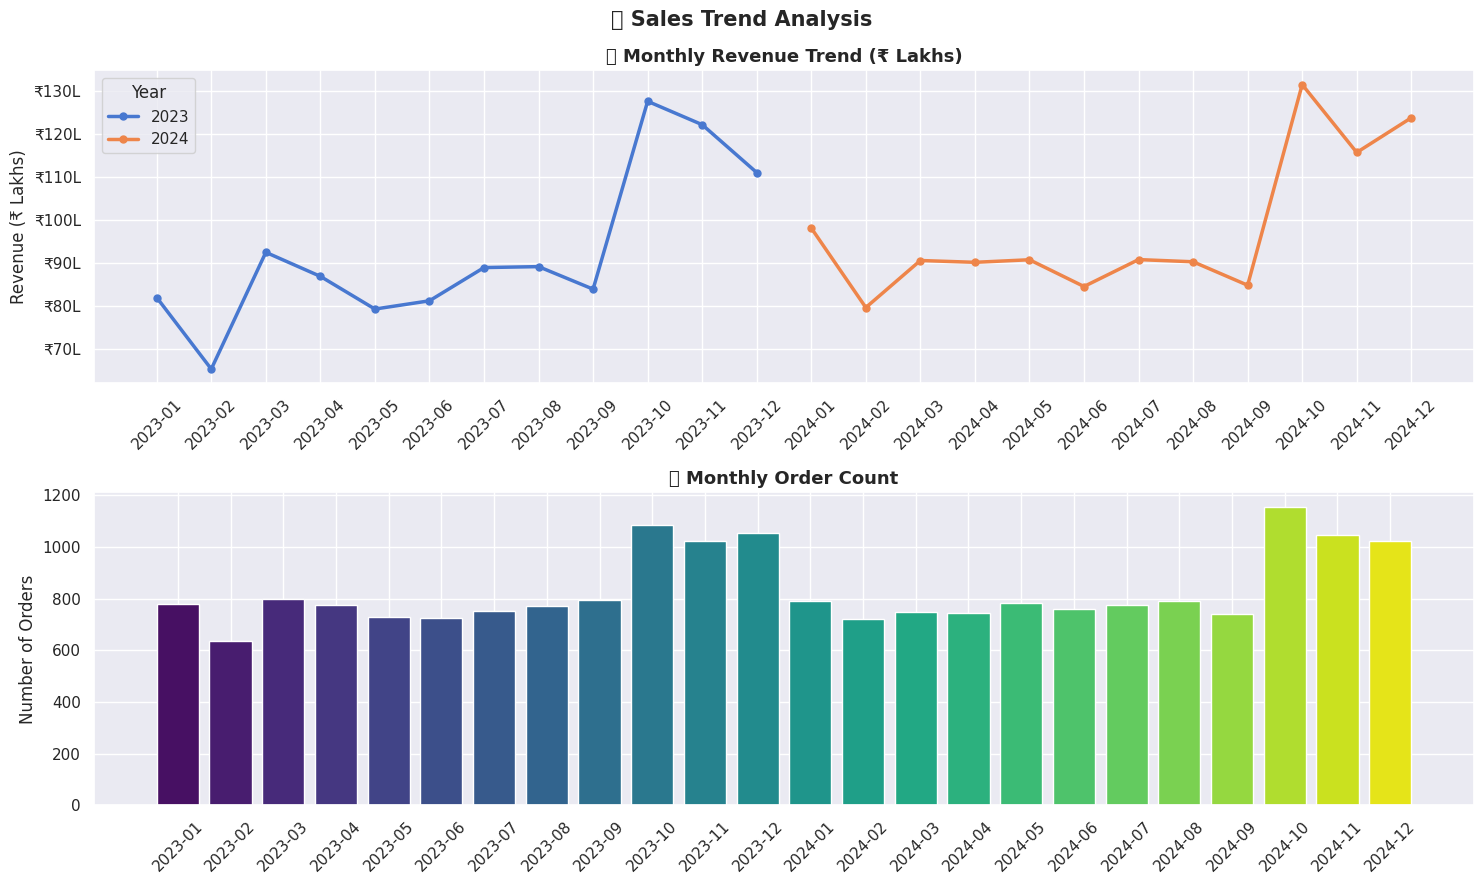

In [6]:
monthly = df.groupby(['year','month']).agg(
    Revenue=('revenue','sum'),
    Orders =('order_id','count'),
    Profit =('profit','sum')
).reset_index()
monthly['Period'] = monthly['year'].astype(str) + '-' + monthly['month'].astype(str).str.zfill(2)
monthly = monthly.sort_values('Period')

fig, axes = plt.subplots(2, 1, figsize=(15, 9))

# Revenue trend
for yr, grp in monthly.groupby('year'):
    axes[0].plot(grp['Period'], grp['Revenue']/1e5,
                 marker='o', linewidth=2.5, markersize=5, label=str(yr))
axes[0].set_title('📅 Monthly Revenue Trend (₹ Lakhs)', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Revenue (₹ Lakhs)')
axes[0].tick_params(axis='x', rotation=45)
axes[0].legend(title='Year')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'₹{x:.0f}L'))

# Order count trend
axes[1].bar(monthly['Period'], monthly['Orders'],
            color=sns.color_palette('viridis', len(monthly)), edgecolor='white')
axes[1].set_title('📦 Monthly Order Count', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Number of Orders')
axes[1].tick_params(axis='x', rotation=45)

plt.suptitle('🛒 Sales Trend Analysis', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('monthly_trend.png', bbox_inches='tight', dpi=150)
plt.show()

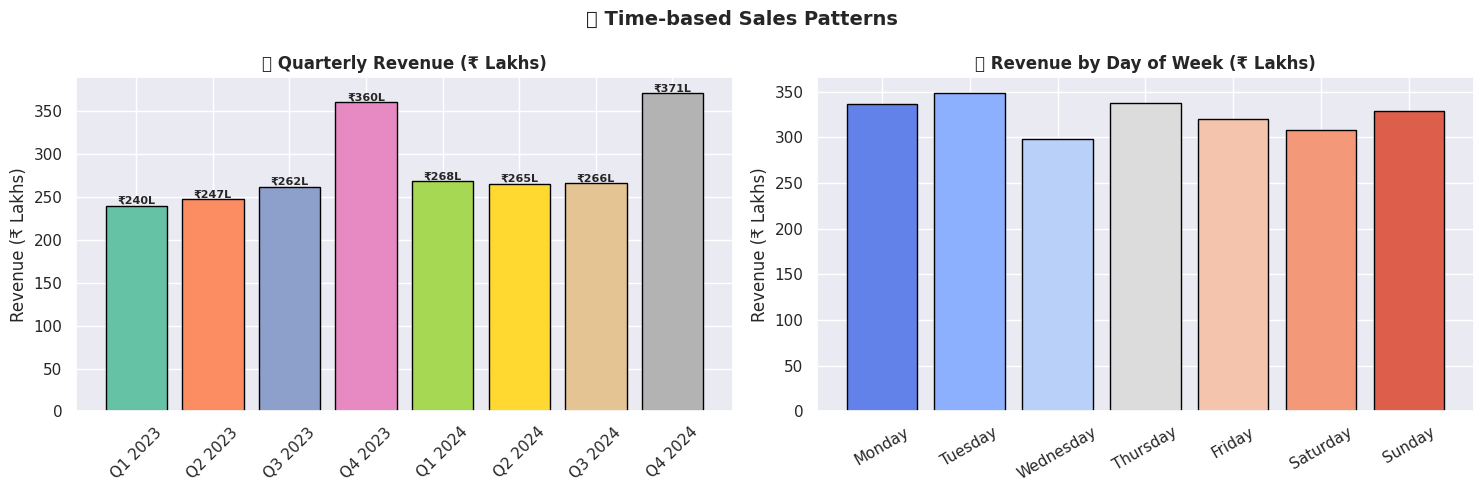

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Quarterly revenue
quarterly = df.groupby(['year','quarter'])['revenue'].sum().reset_index()
quarterly['label'] = 'Q' + quarterly['quarter'].astype(str) + ' ' + quarterly['year'].astype(str)
colors_q = sns.color_palette('Set2', len(quarterly))
bars = axes[0].bar(quarterly['label'], quarterly['revenue']/1e5,
                   color=colors_q, edgecolor='black')
axes[0].set_title('📊 Quarterly Revenue (₹ Lakhs)', fontweight='bold')
axes[0].set_ylabel('Revenue (₹ Lakhs)')
axes[0].tick_params(axis='x', rotation=45)
for bar, val in zip(bars, quarterly['revenue']/1e5):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+2,
                 f'₹{val:.0f}L', ha='center', fontsize=8, fontweight='bold')

# Day of week
dow_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
dow = df.groupby('day_of_week')['revenue'].sum().reindex(dow_order)
axes[1].bar(dow.index, dow.values/1e5,
            color=sns.color_palette('coolwarm', 7), edgecolor='black')
axes[1].set_title('📆 Revenue by Day of Week (₹ Lakhs)', fontweight='bold')
axes[1].set_ylabel('Revenue (₹ Lakhs)')
axes[1].tick_params(axis='x', rotation=30)

plt.suptitle('🗓️ Time-based Sales Patterns', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('quarterly_dow.png', bbox_inches='tight', dpi=150)
plt.show()

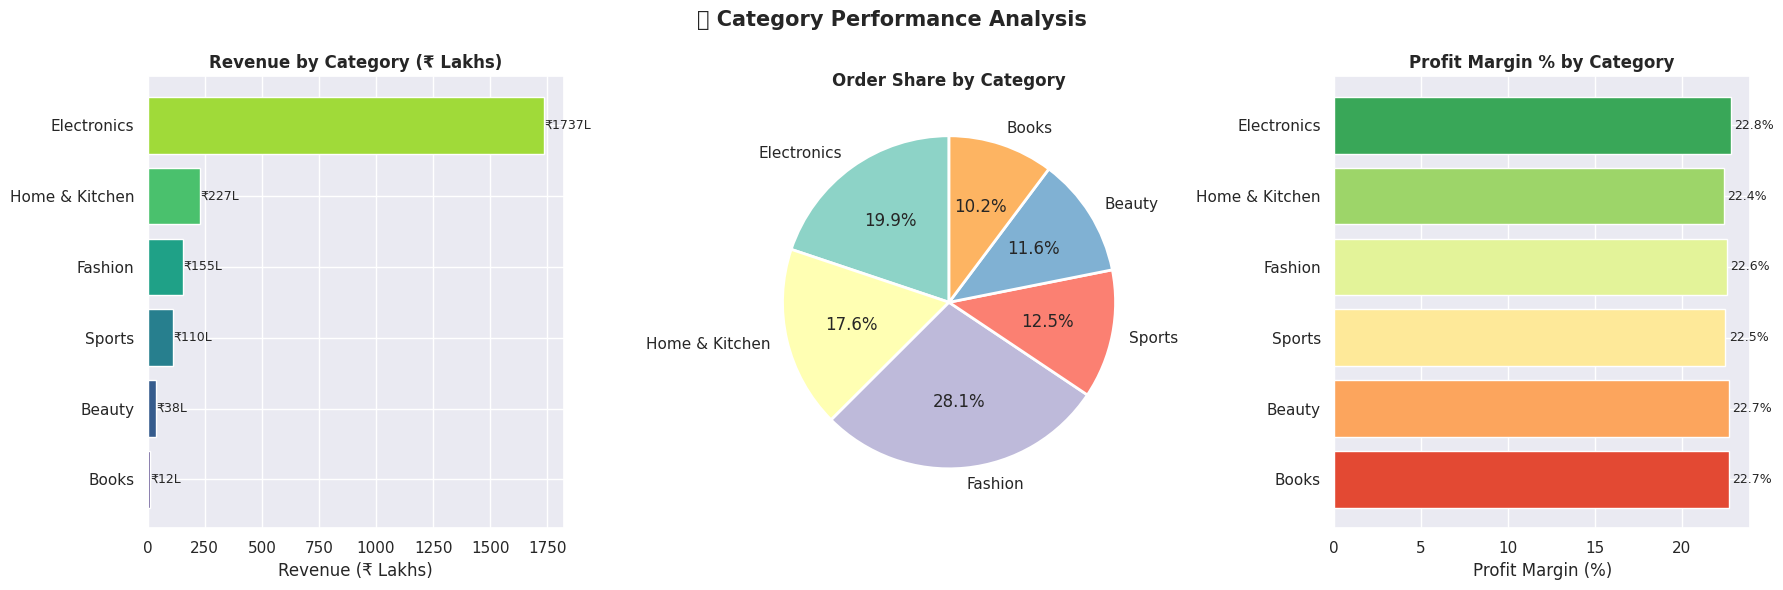


📊 Category Summary Table:
      category  Revenue  Orders  Margin% Avg_Order
   Electronics ₹1736.7L    3970     22.8   ₹43,745
Home & Kitchen  ₹227.4L    3526     22.4    ₹6,451
       Fashion  ₹154.5L    5626     22.6    ₹2,747
        Sports  ₹110.1L    2503     22.5    ₹4,398
        Beauty   ₹38.2L    2329     22.7    ₹1,639
         Books   ₹11.7L    2046     22.7      ₹570


In [8]:
cat_stats = df.groupby('category').agg(
    Revenue=('revenue','sum'),
    Orders =('order_id','count'),
    Profit =('profit','sum'),
    Avg_Order=('revenue','mean')
).reset_index().sort_values('Revenue', ascending=False)
cat_stats['Margin%'] = (cat_stats['Profit'] / cat_stats['Revenue'] * 100).round(1)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Revenue by category
colors_cat = sns.color_palette('viridis', len(cat_stats))
axes[0].barh(cat_stats['category'][::-1], cat_stats['Revenue'][::-1]/1e5, color=colors_cat)
axes[0].set_title('Revenue by Category (₹ Lakhs)', fontweight='bold')
axes[0].set_xlabel('Revenue (₹ Lakhs)')
for i, (rev, cat) in enumerate(zip(cat_stats['Revenue'][::-1], cat_stats['category'][::-1])):
    axes[0].text(rev/1e5+1, i, f'₹{rev/1e5:.0f}L', va='center', fontsize=9)

# Orders share - pie
axes[1].pie(cat_stats['Orders'], labels=cat_stats['category'],
            autopct='%1.1f%%', startangle=90,
            colors=sns.color_palette('Set3', len(cat_stats)),
            wedgeprops={'edgecolor':'white','linewidth':2})
axes[1].set_title('Order Share by Category', fontweight='bold')

# Profit margin by category
axes[2].barh(cat_stats['category'][::-1], cat_stats['Margin%'][::-1],
             color=sns.color_palette('RdYlGn', len(cat_stats)))
axes[2].set_title('Profit Margin % by Category', fontweight='bold')
axes[2].set_xlabel('Profit Margin (%)')
for i, m in enumerate(cat_stats['Margin%'][::-1]):
    axes[2].text(m+0.2, i, f'{m}%', va='center', fontsize=9)

plt.suptitle('🛍️ Category Performance Analysis', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('category_analysis.png', bbox_inches='tight', dpi=150)
plt.show()

print('\n📊 Category Summary Table:')
print(cat_stats[['category','Revenue','Orders','Margin%','Avg_Order']]
      .assign(Revenue=lambda x: x['Revenue'].map(lambda v: f'₹{v/1e5:.1f}L'),
              Avg_Order=lambda x: x['Avg_Order'].map(lambda v: f'₹{v:,.0f}'))
      .to_string(index=False))

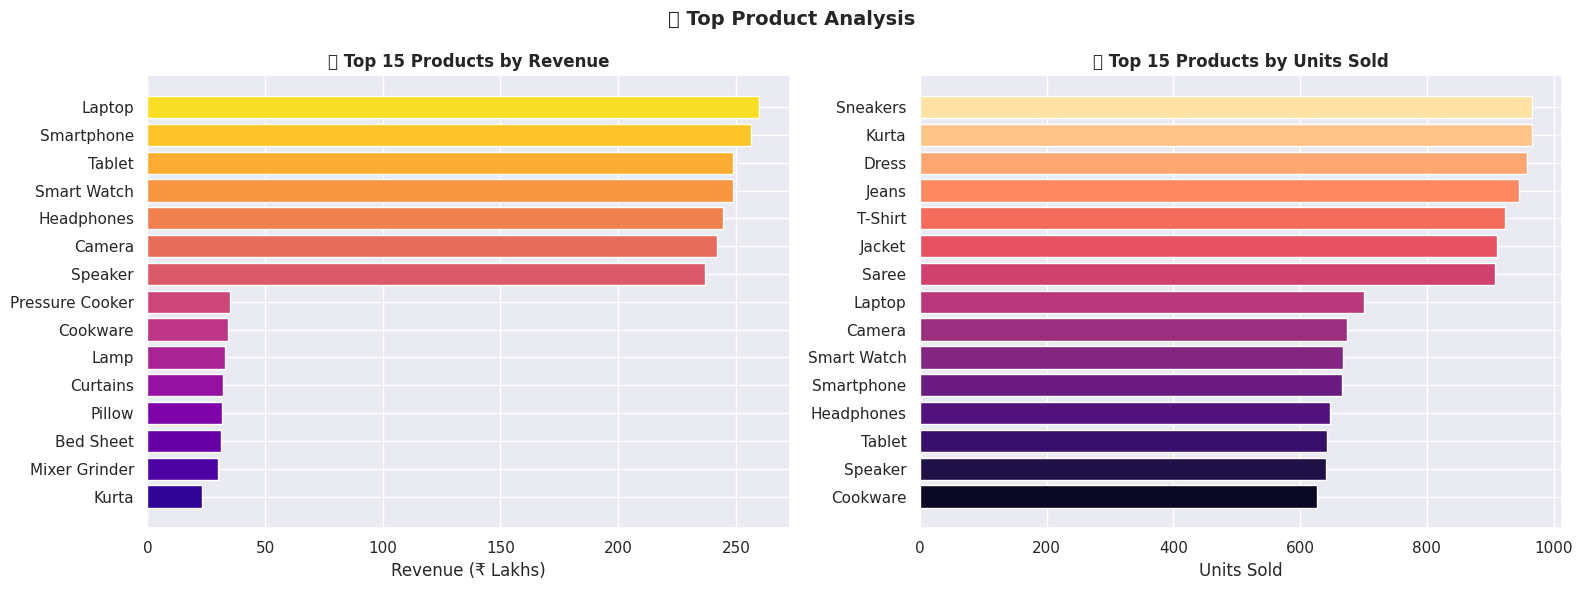

In [9]:
top_products = df.groupby('product').agg(
    Revenue=('revenue','sum'),
    Units  =('quantity','sum'),
    Orders =('order_id','count')
).reset_index().sort_values('Revenue', ascending=False).head(15)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Top 15 by revenue
axes[0].barh(top_products['product'][::-1],
             top_products['Revenue'][::-1]/1e5,
             color=sns.color_palette('plasma', 15))
axes[0].set_title('🏆 Top 15 Products by Revenue', fontweight='bold')
axes[0].set_xlabel('Revenue (₹ Lakhs)')

# Top 15 by units sold
top_units = df.groupby('product')['quantity'].sum().sort_values(ascending=False).head(15)
axes[1].barh(top_units.index[::-1], top_units.values[::-1],
             color=sns.color_palette('magma', 15))
axes[1].set_title('📦 Top 15 Products by Units Sold', fontweight='bold')
axes[1].set_xlabel('Units Sold')

plt.suptitle('🏆 Top Product Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('top_products.png', bbox_inches='tight', dpi=150)
plt.show()

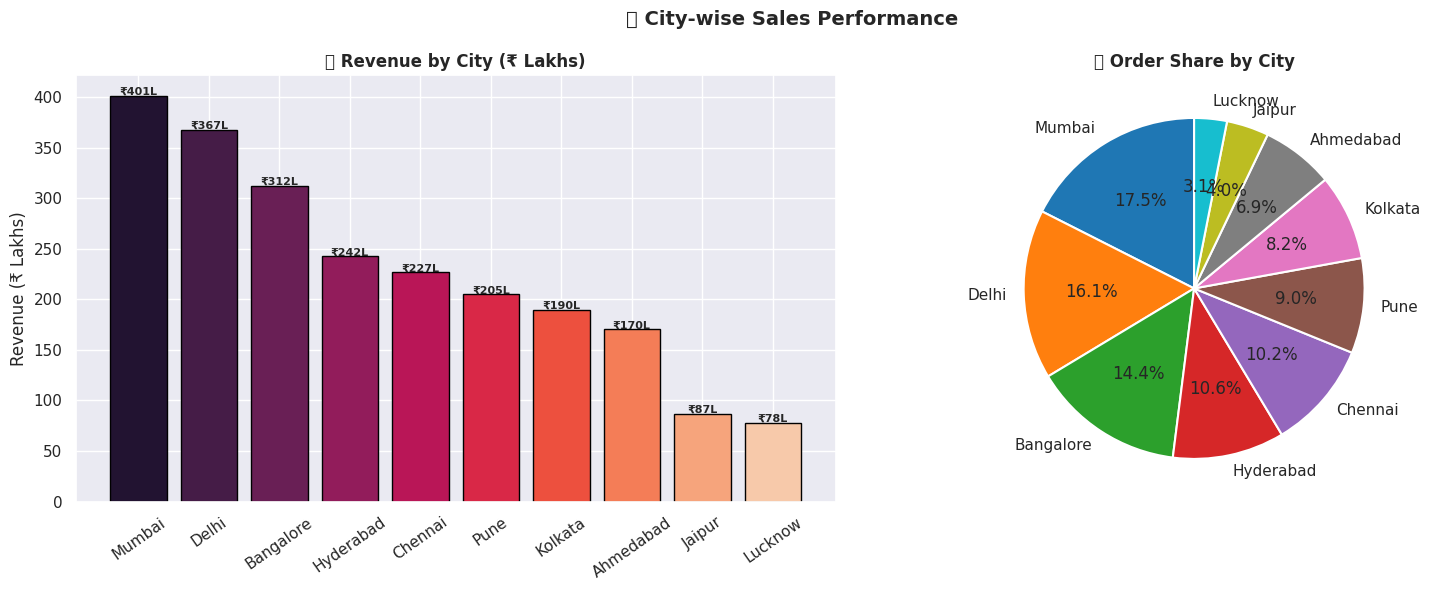


🌆 City Summary:
     city Revenue  Orders  Customers Profit
   Mumbai ₹401.3L    3508        980 ₹91.3L
    Delhi ₹367.3L    3218        972 ₹82.2L
Bangalore ₹311.9L    2875        952 ₹71.3L
Hyderabad ₹242.3L    2120        873 ₹54.6L
  Chennai ₹226.6L    2049        875 ₹51.4L
     Pune ₹204.9L    1802        828 ₹45.7L
  Kolkata ₹189.6L    1632        795 ₹43.9L
Ahmedabad ₹170.2L    1376        745 ₹39.4L
   Jaipur  ₹86.6L     800        542 ₹19.9L
  Lucknow  ₹78.0L     620        454 ₹17.9L


In [10]:
city_stats = df.groupby('city').agg(
    Revenue  =('revenue','sum'),
    Orders   =('order_id','count'),
    Customers=('customer_id','nunique'),
    Profit   =('profit','sum')
).reset_index().sort_values('Revenue', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Revenue by city
bars = axes[0].bar(city_stats['city'], city_stats['Revenue']/1e5,
                   color=sns.color_palette('rocket', len(city_stats)), edgecolor='black')
axes[0].set_title('💰 Revenue by City (₹ Lakhs)', fontweight='bold')
axes[0].set_ylabel('Revenue (₹ Lakhs)')
axes[0].tick_params(axis='x', rotation=35)
for bar, val in zip(bars, city_stats['Revenue']/1e5):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+1,
                 f'₹{val:.0f}L', ha='center', fontsize=8, fontweight='bold')

# Orders by city
axes[1].pie(city_stats['Orders'], labels=city_stats['city'],
            autopct='%1.1f%%', startangle=90,
            colors=sns.color_palette('tab10', len(city_stats)),
            wedgeprops={'edgecolor':'white','linewidth':1.5})
axes[1].set_title('📦 Order Share by City', fontweight='bold')

plt.suptitle('🌆 City-wise Sales Performance', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('city_analysis.png', bbox_inches='tight', dpi=150)
plt.show()

print('\n🌆 City Summary:')
print(city_stats.assign(
    Revenue=lambda x: x['Revenue'].map(lambda v: f'₹{v/1e5:.1f}L'),
    Profit =lambda x: x['Profit'].map(lambda v:  f'₹{v/1e5:.1f}L')
).to_string(index=False))

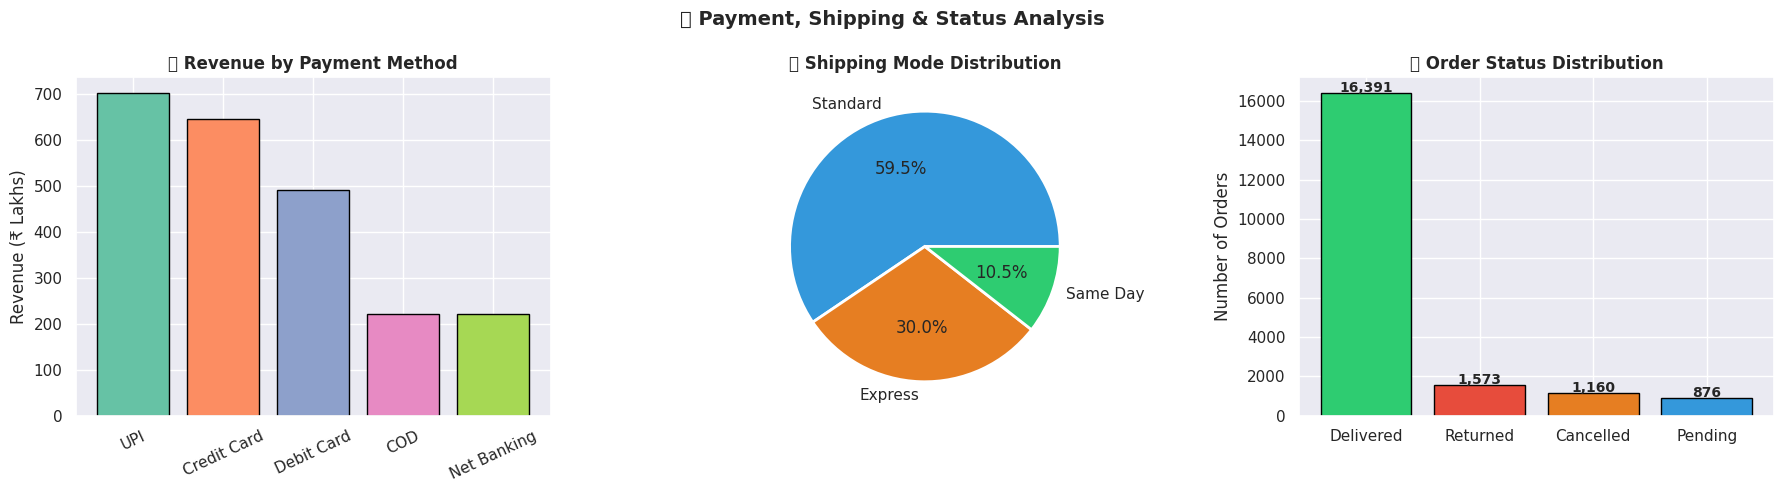

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Payment method
pay_rev = df.groupby('payment_method')['revenue'].sum().sort_values(ascending=False)
axes[0].bar(pay_rev.index, pay_rev.values/1e5,
            color=sns.color_palette('Set2', len(pay_rev)), edgecolor='black')
axes[0].set_title('💳 Revenue by Payment Method', fontweight='bold')
axes[0].set_ylabel('Revenue (₹ Lakhs)')
axes[0].tick_params(axis='x', rotation=25)

# Shipping mode
ship_count = df['ship_mode'].value_counts()
axes[1].pie(ship_count.values, labels=ship_count.index, autopct='%1.1f%%',
            colors=['#3498db','#e67e22','#2ecc71'],
            wedgeprops={'edgecolor':'white','linewidth':2})
axes[1].set_title('🚚 Shipping Mode Distribution', fontweight='bold')

# Order status
status_count = df['status'].value_counts()
status_colors = {'Delivered':'#2ecc71','Returned':'#e74c3c',
                 'Cancelled':'#e67e22','Pending':'#3498db'}
colors_st = [status_colors[s] for s in status_count.index]
axes[2].bar(status_count.index, status_count.values,
            color=colors_st, edgecolor='black')
axes[2].set_title('📋 Order Status Distribution', fontweight='bold')
axes[2].set_ylabel('Number of Orders')
for i, v in enumerate(status_count.values):
    axes[2].text(i, v+50, f'{v:,}', ha='center', fontsize=10, fontweight='bold')

plt.suptitle('💳 Payment, Shipping & Status Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('payment_shipping.png', bbox_inches='tight', dpi=150)
plt.show()

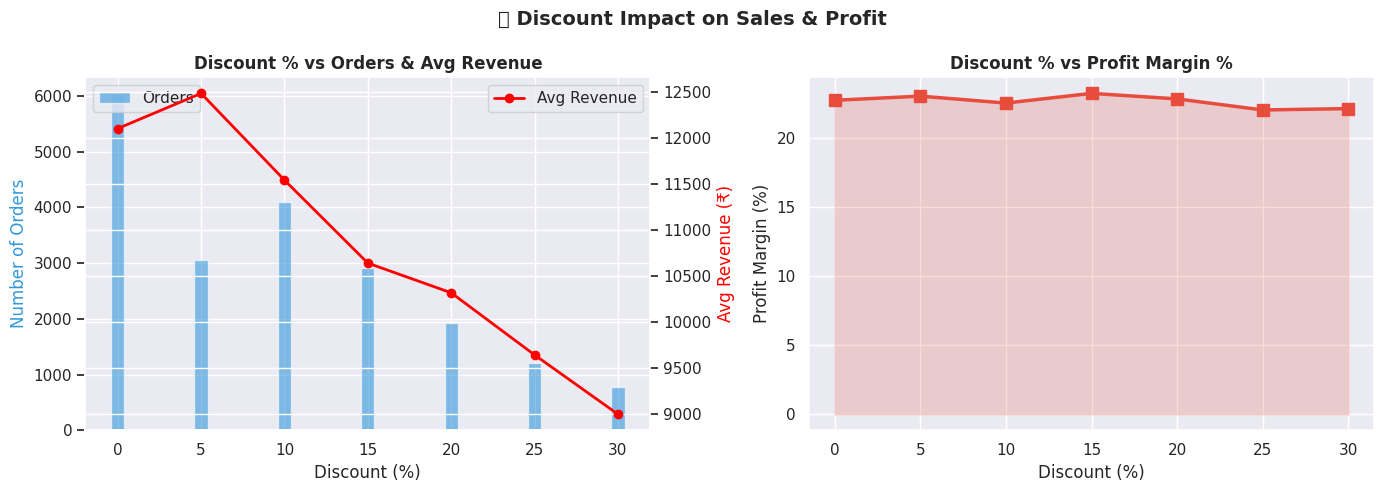

In [12]:
disc_stats = df.groupby('discount_pct').agg(
    Orders  =('order_id','count'),
    Revenue =('revenue','sum'),
    Profit  =('profit','sum'),
    Avg_Rev =('revenue','mean')
).reset_index()
disc_stats['Margin%'] = (disc_stats['Profit'] / disc_stats['Revenue'] * 100).round(1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax2 = axes[0].twinx()
axes[0].bar(disc_stats['discount_pct'], disc_stats['Orders'],
            alpha=0.6, color='#3498db', label='Orders')
ax2.plot(disc_stats['discount_pct'], disc_stats['Avg_Rev'],
         color='red', marker='o', linewidth=2, label='Avg Revenue')
axes[0].set_title('Discount % vs Orders & Avg Revenue', fontweight='bold')
axes[0].set_xlabel('Discount (%)')
axes[0].set_ylabel('Number of Orders', color='#3498db')
ax2.set_ylabel('Avg Revenue (₹)', color='red')
axes[0].legend(loc='upper left')
ax2.legend(loc='upper right')

axes[1].plot(disc_stats['discount_pct'], disc_stats['Margin%'],
             marker='s', color='#e74c3c', linewidth=2.5, markersize=8)
axes[1].fill_between(disc_stats['discount_pct'], disc_stats['Margin%'],
                     alpha=0.2, color='#e74c3c')
axes[1].set_title('Discount % vs Profit Margin %', fontweight='bold')
axes[1].set_xlabel('Discount (%)')
axes[1].set_ylabel('Profit Margin (%)')

plt.suptitle('🎯 Discount Impact on Sales & Profit', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('discount_analysis.png', bbox_inches='tight', dpi=150)
plt.show()

In [13]:
snapshot_date = df['order_date'].max() + timedelta(days=1)

rfm = df.groupby('customer_id').agg(
    Recency  =('order_date', lambda x: (snapshot_date - x.max()).days),
    Frequency=('order_id',   'count'),
    Monetary =('revenue',    'sum')
).reset_index()

# Score 1–4 for each dimension
rfm['R_Score'] = pd.qcut(rfm['Recency'],   q=4, labels=[4,3,2,1]).astype(int)
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), q=4, labels=[1,2,3,4]).astype(int)
rfm['M_Score'] = pd.qcut(rfm['Monetary'].rank(method='first'),  q=4, labels=[1,2,3,4]).astype(int)
rfm['RFM_Score'] = rfm['R_Score'] + rfm['F_Score'] + rfm['M_Score']

def rfm_segment(score):
    if score >= 10: return 'Champions'
    elif score >= 8: return 'Loyal Customers'
    elif score >= 6: return 'Potential Loyalists'
    elif score >= 4: return 'At Risk'
    else:            return 'Lost'

rfm['Segment'] = rfm['RFM_Score'].apply(rfm_segment)

print('✅ RFM Scoring complete!')
print('\n📊 Segment Distribution:')
print(rfm['Segment'].value_counts().to_string())
print('\n📊 RFM Stats by Segment:')
rfm.groupby('Segment')[['Recency','Frequency','Monetary']].mean().round(1)

✅ RFM Scoring complete!

📊 Segment Distribution:
Segment
Loyal Customers        320
Potential Loyalists    276
Champions              209
At Risk                139
Lost                    56

📊 RFM Stats by Segment:


,Recency,Frequency,Monetary
Segment,,,
At Risk,47.8,16.2,137687.9
Champions,11.6,24.5,345651.8
Lost,83.8,13.8,96693.2
Loyal Customers,21.5,21.2,244380.7
Potential Loyalists,34.1,18.4,191531.5


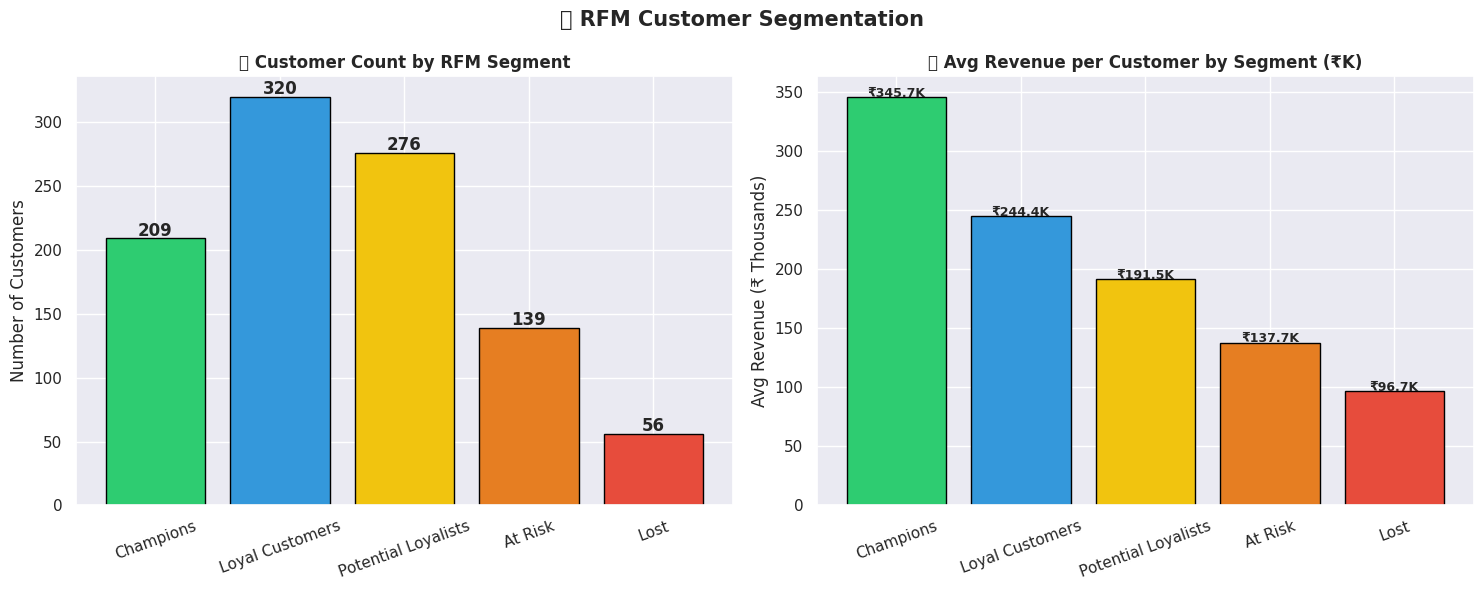

In [14]:
seg_order = ['Champions','Loyal Customers','Potential Loyalists','At Risk','Lost']
seg_colors = ['#2ecc71','#3498db','#f1c40f','#e67e22','#e74c3c']
seg_count  = rfm['Segment'].value_counts().reindex(seg_order).fillna(0)
seg_money  = rfm.groupby('Segment')['Monetary'].mean().reindex(seg_order).fillna(0)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Segment count
axes[0].bar(seg_count.index, seg_count.values,
            color=seg_colors, edgecolor='black')
axes[0].set_title('👥 Customer Count by RFM Segment', fontweight='bold')
axes[0].set_ylabel('Number of Customers')
axes[0].tick_params(axis='x', rotation=20)
for i, v in enumerate(seg_count.values):
    axes[0].text(i, v+2, str(int(v)), ha='center', fontweight='bold')

# Avg monetary by segment
axes[1].bar(seg_money.index, seg_money.values/1e3,
            color=seg_colors, edgecolor='black')
axes[1].set_title('💰 Avg Revenue per Customer by Segment (₹K)', fontweight='bold')
axes[1].set_ylabel('Avg Revenue (₹ Thousands)')
axes[1].tick_params(axis='x', rotation=20)
for i, v in enumerate(seg_money.values):
    axes[1].text(i, v/1e3+0.2, f'₹{v/1e3:.1f}K', ha='center', fontsize=9, fontweight='bold')

plt.suptitle('🎯 RFM Customer Segmentation', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('rfm_segments.png', bbox_inches='tight', dpi=150)
plt.show()

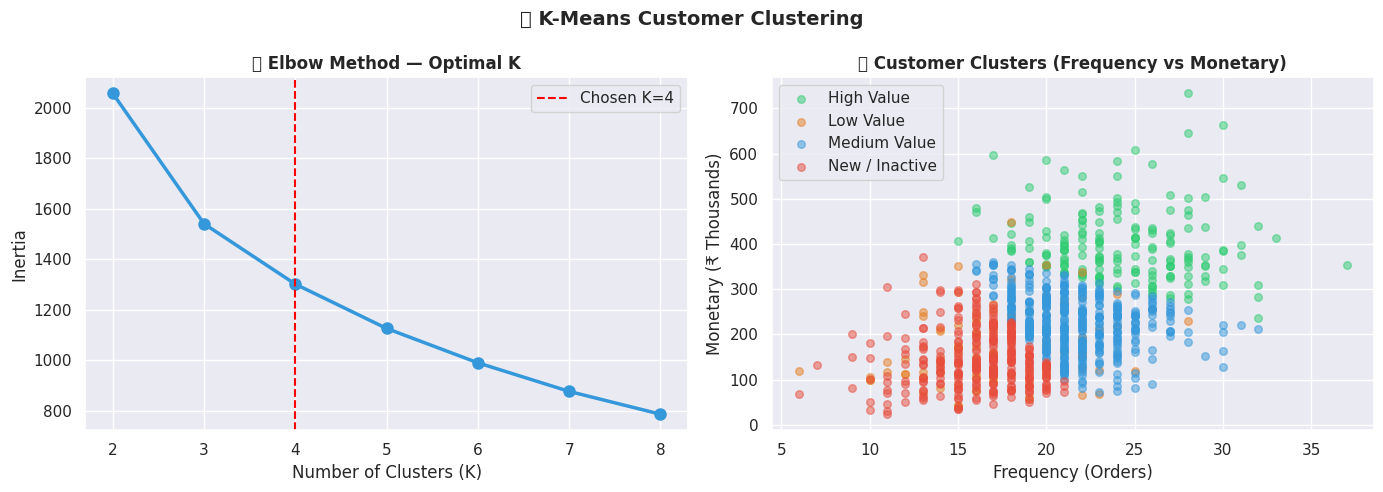


📊 Cluster Summary:


,Recency,Frequency,Monetary
Cluster_Label,,,
High Value,21.1,24.2,400271.6
Low Value,99.0,17.2,172049.2
Medium Value,22.9,21.7,226294.2
New / Inactive,22.6,16.2,146571.2


In [15]:
# Scale RFM values
scaler   = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm[['Recency','Frequency','Monetary']])

# Find optimal K using Elbow Method
inertias = []
K_range  = range(2, 9)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(rfm_scaled)
    inertias.append(km.inertia_)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Elbow curve
axes[0].plot(K_range, inertias, marker='o', color='#3498db', linewidth=2.5, markersize=8)
axes[0].set_title('📐 Elbow Method — Optimal K', fontweight='bold')
axes[0].set_xlabel('Number of Clusters (K)')
axes[0].set_ylabel('Inertia')
axes[0].axvline(x=4, color='red', linestyle='--', label='Chosen K=4')
axes[0].legend()

# Final clustering with K=4
km_final = KMeans(n_clusters=4, random_state=42, n_init=10)
rfm['Cluster'] = km_final.fit_predict(rfm_scaled)

cluster_labels = {0:'High Value', 1:'Medium Value', 2:'Low Value', 3:'New / Inactive'}
cluster_stats  = rfm.groupby('Cluster')[['Recency','Frequency','Monetary']].mean().round(1)
# Re-label by mean Monetary descending
order_map = cluster_stats['Monetary'].rank(ascending=False).astype(int) - 1
label_map = {c: list(cluster_labels.values())[r] for c, r in order_map.items()}
rfm['Cluster_Label'] = rfm['Cluster'].map(label_map)

# Scatter
cluster_colors_map = {'High Value':'#2ecc71','Medium Value':'#3498db',
                      'Low Value':'#e67e22','New / Inactive':'#e74c3c'}
for lbl, grp in rfm.groupby('Cluster_Label'):
    axes[1].scatter(grp['Frequency'], grp['Monetary']/1e3,
                    alpha=0.5, s=30, label=lbl,
                    color=cluster_colors_map.get(lbl, 'grey'))
axes[1].set_title('🔵 Customer Clusters (Frequency vs Monetary)', fontweight='bold')
axes[1].set_xlabel('Frequency (Orders)')
axes[1].set_ylabel('Monetary (₹ Thousands)')
axes[1].legend()

plt.suptitle('🔵 K-Means Customer Clustering', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('kmeans_clusters.png', bbox_inches='tight', dpi=150)
plt.show()

print('\n📊 Cluster Summary:')
rfm.groupby('Cluster_Label')[['Recency','Frequency','Monetary']].mean().round(1)

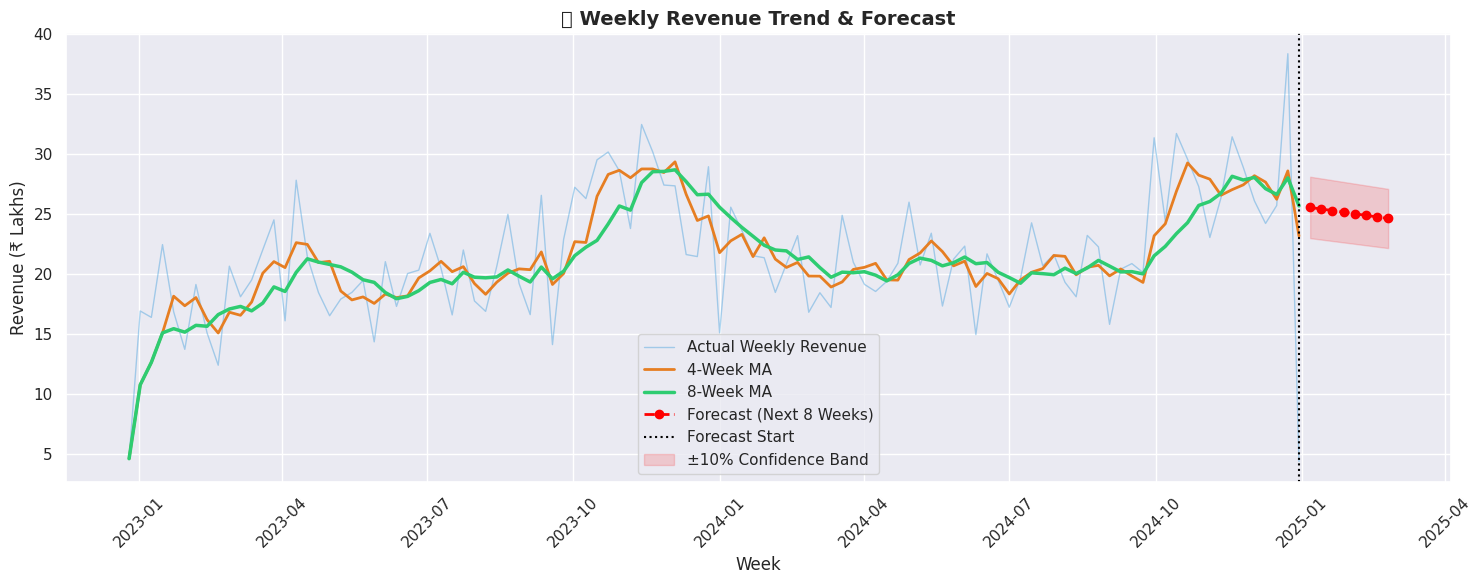


📅 8-Week Revenue Forecast:
   Week of 06 Jan 2025 → ₹ 25.54 Lakhs
   Week of 13 Jan 2025 → ₹ 25.41 Lakhs
   Week of 20 Jan 2025 → ₹ 25.28 Lakhs
   Week of 27 Jan 2025 → ₹ 25.15 Lakhs
   Week of 03 Feb 2025 → ₹ 25.02 Lakhs
   Week of 10 Feb 2025 → ₹ 24.89 Lakhs
   Week of 17 Feb 2025 → ₹ 24.76 Lakhs
   Week of 24 Feb 2025 → ₹ 24.63 Lakhs


In [16]:
# Weekly revenue
df['week'] = df['order_date'].dt.to_period('W').dt.start_time
weekly_rev = df.groupby('week')['revenue'].sum().reset_index()
weekly_rev.columns = ['week','revenue']
weekly_rev = weekly_rev.sort_values('week').reset_index(drop=True)

# 4-week & 8-week moving average
weekly_rev['MA4']  = weekly_rev['revenue'].rolling(window=4, min_periods=1).mean()
weekly_rev['MA8']  = weekly_rev['revenue'].rolling(window=8, min_periods=1).mean()

# Forecast next 8 weeks using last MA8
last_date  = weekly_rev['week'].max()
last_ma8   = weekly_rev['MA8'].iloc[-1]
trend_slope= (weekly_rev['MA8'].iloc[-1] - weekly_rev['MA8'].iloc[-8]) / 8
forecast_dates  = [last_date + timedelta(weeks=i) for i in range(1, 9)]
forecast_values = [last_ma8 + trend_slope * i for i in range(1, 9)]

plt.figure(figsize=(15, 6))
plt.plot(weekly_rev['week'], weekly_rev['revenue']/1e5,
         alpha=0.4, color='#3498db', linewidth=1, label='Actual Weekly Revenue')
plt.plot(weekly_rev['week'], weekly_rev['MA4']/1e5,
         color='#e67e22', linewidth=2, label='4-Week MA')
plt.plot(weekly_rev['week'], weekly_rev['MA8']/1e5,
         color='#2ecc71', linewidth=2.5, label='8-Week MA')
plt.plot(forecast_dates, [v/1e5 for v in forecast_values],
         color='red', linewidth=2, linestyle='--', marker='o',
         markersize=6, label='Forecast (Next 8 Weeks)')
plt.axvline(x=last_date, color='black', linestyle=':', linewidth=1.5, label='Forecast Start')
plt.fill_between(forecast_dates,
                 [v/1e5*0.90 for v in forecast_values],
                 [v/1e5*1.10 for v in forecast_values],
                 alpha=0.15, color='red', label='±10% Confidence Band')
plt.title('📈 Weekly Revenue Trend & Forecast', fontsize=14, fontweight='bold')
plt.xlabel('Week')
plt.ylabel('Revenue (₹ Lakhs)')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('revenue_forecast.png', bbox_inches='tight', dpi=150)
plt.show()

print('\n📅 8-Week Revenue Forecast:')
for d, v in zip(forecast_dates, forecast_values):
    print(f'   Week of {d.strftime("%d %b %Y")} → ₹ {v/1e5:.2f} Lakhs')

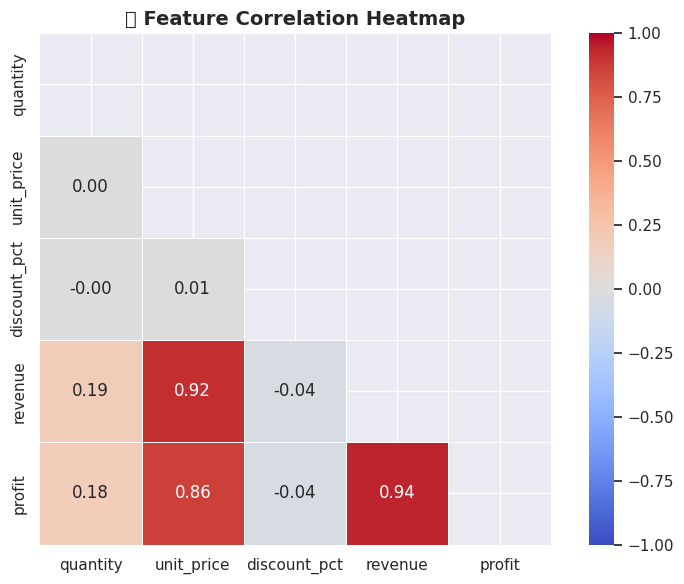

In [17]:
num_cols = ['quantity','unit_price','discount_pct','revenue','profit']
corr = df[num_cols].corr()

plt.figure(figsize=(8, 6))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            mask=mask, vmin=-1, vmax=1, square=True, linewidths=0.5)
plt.title('🔥 Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', bbox_inches='tight', dpi=150)
plt.show()

In [18]:
top_cat    = cat_stats.iloc[0]['category']
top_city   = city_stats.iloc[0]['city']
top_prod   = top_products.iloc[0]['product']
top_pay    = df['payment_method'].value_counts().idxmax()
champ_count= (rfm['Segment'] == 'Champions').sum()

print('=' * 62)
print('🛒  E-COMMERCE SALES DASHBOARD — FINAL SUMMARY')
print('=' * 62)
print(f'\n📦 ORDERS')
print(f'   Total Orders         : {total_orders:,}')
print(f'   Delivered            : {(df["status"]=="Delivered").sum():,}  ({(df["status"]=="Delivered").mean()*100:.1f}%)')
print(f'   Returned             : {(df["status"]=="Returned").sum():,}  ({return_rate:.1f}%)')
print(f'   Cancelled            : {(df["status"]=="Cancelled").sum():,}  ({cancel_rate:.1f}%)')
print(f'\n💰 REVENUE')
print(f'   Total Revenue        : ₹ {total_revenue/1e7:.2f} Crore')
print(f'   Total Profit         : ₹ {total_profit/1e7:.2f} Crore')
print(f'   Avg Order Value      : ₹ {avg_order_value:,.0f}')
print(f'   Profit Margin        : {profit_margin:.1f}%')
print(f'\n🏆 TOP PERFORMERS')
print(f'   Top Category         : {top_cat}')
print(f'   Top City             : {top_city}')
print(f'   Top Product          : {top_prod}')
print(f'   Top Payment Method   : {top_pay}')
print(f'\n👥 CUSTOMERS')
print(f'   Unique Customers     : {total_customers:,}')
print(f'   Champions (RFM)      : {champ_count} customers')
print(f'   Avg Orders/Customer  : {total_orders/total_customers:.1f}')
print(f'\n✅ Analysis Complete!')

🛒  E-COMMERCE SALES DASHBOARD — FINAL SUMMARY

📦 ORDERS
   Total Orders         : 20,000
   Delivered            : 16,391  (82.0%)
   Returned             : 1,573  (7.9%)
   Cancelled            : 1,160  (5.8%)

💰 REVENUE
   Total Revenue        : ₹ 22.79 Crore
   Total Profit         : ₹ 5.18 Crore
   Avg Order Value      : ₹ 11,393
   Profit Margin        : 22.7%

🏆 TOP PERFORMERS
   Top Category         : Electronics
   Top City             : Mumbai
   Top Product          : Laptop
   Top Payment Method   : UPI

👥 CUSTOMERS
   Unique Customers     : 1,000
   Champions (RFM)      : 209 customers
   Avg Orders/Customer  : 20.0

✅ Analysis Complete!
